# LOAD DATA

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Nov  8 16:01:23 2022

@author: alex
"""


from copy import deepcopy
import os
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme(style="ticks", palette="pastel")


def add_chsn(subject_data):
    list_position_pairs = [(x,y) for x,y in zip(subject_data['state'], subject_data['chosen state'])]
    times_seen_ = []
    for county in range(0, len(list_position_pairs)):
        seen_ = list_position_pairs[:county]
        current_pair_ = list_position_pairs[county]
        count_ = seen_.count(current_pair_)
        times_seen_.append(count_) 
    subject_data['times chosen'] = times_seen_
    return subject_data



In [11]:

os.chdir('/data/pt_02747_hippo/1_day_one/1_training/responses/')
#os.chdir('/data/pt_02747_hippo/2_day_two/3_pretraining/responses/')

data_dir = '/data/pt_02747/action_hippo/data/' # take only subjects that have fMRI data

subs = [os.path.basename(f) for f in os.listdir(data_dir) if 'sub' in f]

subs_behav = []

for sub in subs:
    sub_num = sub.split('-')[1]
    if sub_num[0] == '0':
        sub_num = sub_num[1]
    subs_behav.append('sub-'+sub_num)


files = [os.path.basename(f) for f in os.listdir('/data/pt_02747_hippo/1_day_one/1_training/responses/')]
#files = [os.path.basename(f) for f in os.listdir('/data/pt_02747_hippo/2_day_two/3_pretraining/responses/')]
subject_names = [i for i in files if i.split('_')[0] in subs_behav and 'csv' in i]


list_all_data = []
for name in subject_names:
    list_all_data.append(add_chsn(pd.read_csv(name)))
    
print('Number of subjects:', len(list_all_data))

Number of subjects: 57


In [12]:
    
    
all_data = pd.concat(list_all_data, join='inner', ignore_index=True)



all_data["rule"] = pd.to_numeric(all_data["rule"], errors='coerce')
all_data["chosen position"] = pd.to_numeric(all_data["chosen position"], errors='coerce')
all_data["position"] = pd.to_numeric(all_data["position"], errors='coerce')
all_data['abstract position'] = all_data['position']%5
all_data['abstract position 10'] = all_data['position']%10
all_data['abstract position chosen'] = all_data['chosen position']%5
all_data['abstract position chosen 10'] = all_data['chosen position']%10

all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

# sort by subject
all_data = all_data.sort_values(by=['subject'])

all_data.head()

,state,position,chosen state,chosen position,response,rt,correctness,other selection,other position,time,...,guided,condition,subject,block,date,times chosen,abstract position,abstract position 10,abstract position chosen,abstract position chosen 10
61247,189,169,191,171.0,m,1.249958,1,190,170,2348.953398,...,GEN,gen,sub-1,20,20230601_1326,0,4,9,1.0,1.0
61009,24,4,26,6.0,l,1.032618,1,23,3,1535.211686,...,TEST,test,sub-1,14,20230601_1326,8,4,4,1.0,6.0
61010,43,23,42,22.0,m,1.460851,1,45,25,1538.711702,...,TEST,test,sub-1,14,20230601_1326,0,3,3,2.0,2.0
61011,31,11,29,9.0,m,0.888973,1,32,12,1541.995071,...,TEST,test,sub-1,14,20230601_1326,3,1,1,4.0,9.0
61012,31,11,29,9.0,m,0.797728,1,30,10,1545.495124,...,TEST,test,sub-1,14,20230601_1326,4,1,1,4.0,9.0


In [ ]:
df = deepcopy(all_data)

test_data = deepcopy(df.loc[df['correctness'] != 'TRAIN'])
test_data['correctness'] = pd.to_numeric(test_data["correctness"], errors='coerce')
train_data = deepcopy(df.loc[df['correctness'] == 'TRAIN'])
gen_df = deepcopy(test_data.loc[test_data['guided'] == 'GEN'])


In [14]:
# create new df where we take only the last ten blocks of test data and exclude GEN trials
test_data = test_data.loc[test_data['block'] ==20]
test_data = test_data.loc[test_data['guided'] == 'GEN']

# for each subject, calculate the mean accuracy and mean RT in these last ten blocks

performances = []
rts = []
for sub in test_data['subject'].unique():
    sub_data = test_data.loc[test_data['subject'] == sub]
    # performance is the number of correctness==1 out of the total number of trials
    performance = sub_data['correctness'].sum() / len(sub_data)
    performances.append(performance)
    # RT is the mean RT of the non-missed trials, i.e. correctness==1 or correctness==0
    rt = sub_data.loc[(sub_data['correctness'] == 1) | (sub_data['correctness'] == 0)]['rt'].mean()
    rts.append(rt)


# print mean performance and mean RT across subjects
print('Mean performance:', sum(performances) / len(performances))
print('Mean RT:', sum(rts) / len(rts))

# stds
print('Performance std:', pd.Series(performances).std())
print('RT std:', pd.Series(rts).std())


Mean performance: 0.7624269005847952
Mean RT: 1.2757259552075062
Performance std: 0.14325200841255248
RT std: 0.13870715671942244


# Generalisation 

/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categoric

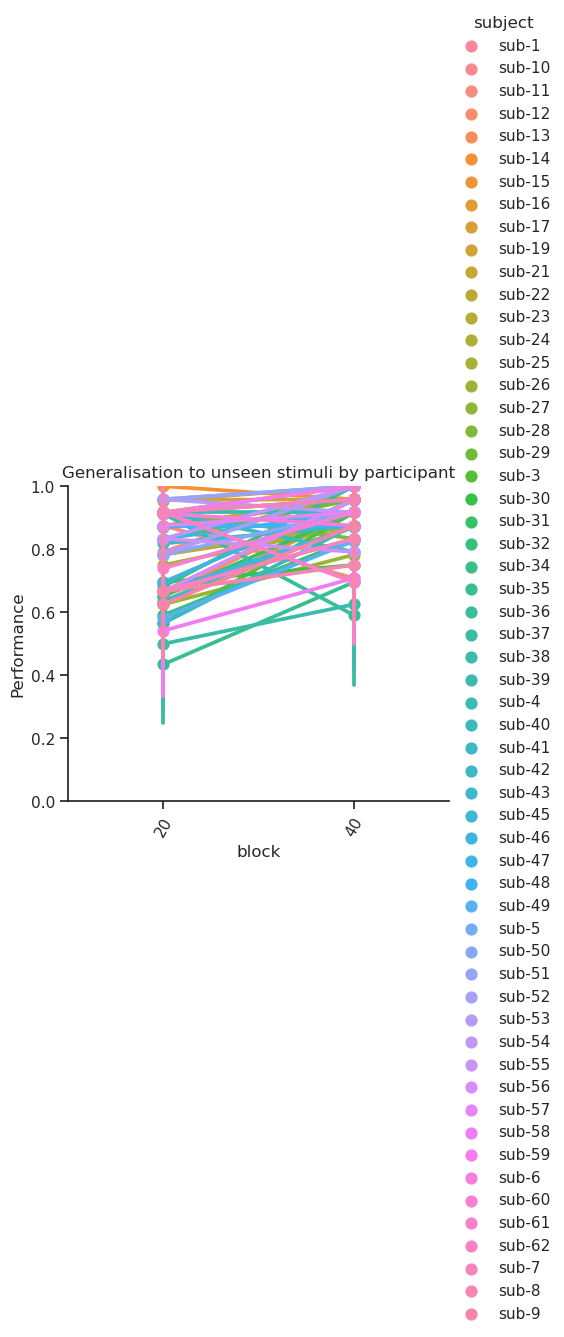

In [9]:
sns.set_theme(style="ticks", palette="bright")

g = sns.catplot(
            x="block", 
            y="correctness",
            hue="subject",
            data=gen_df,
            #data=gen_df.loc[(gen_df['subject'] != 'sub-10') & (gen_df['subject'] != 'sub-11')],
            kind='point',
            height = 4,
            aspect = 1.2,
            legend=True,
            errorbar=('ci', 95),
            orient='v',
            join=True)
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Generalisation to unseen stimuli by participant')
plt.xticks(rotation=60) 
plt.ylabel('Performance')
#g.set_xticklabels(['Numbers', 'Letters'])
# set y axis from 0 to 1
plt.ylim(0,1)

plt.show()

/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categoric

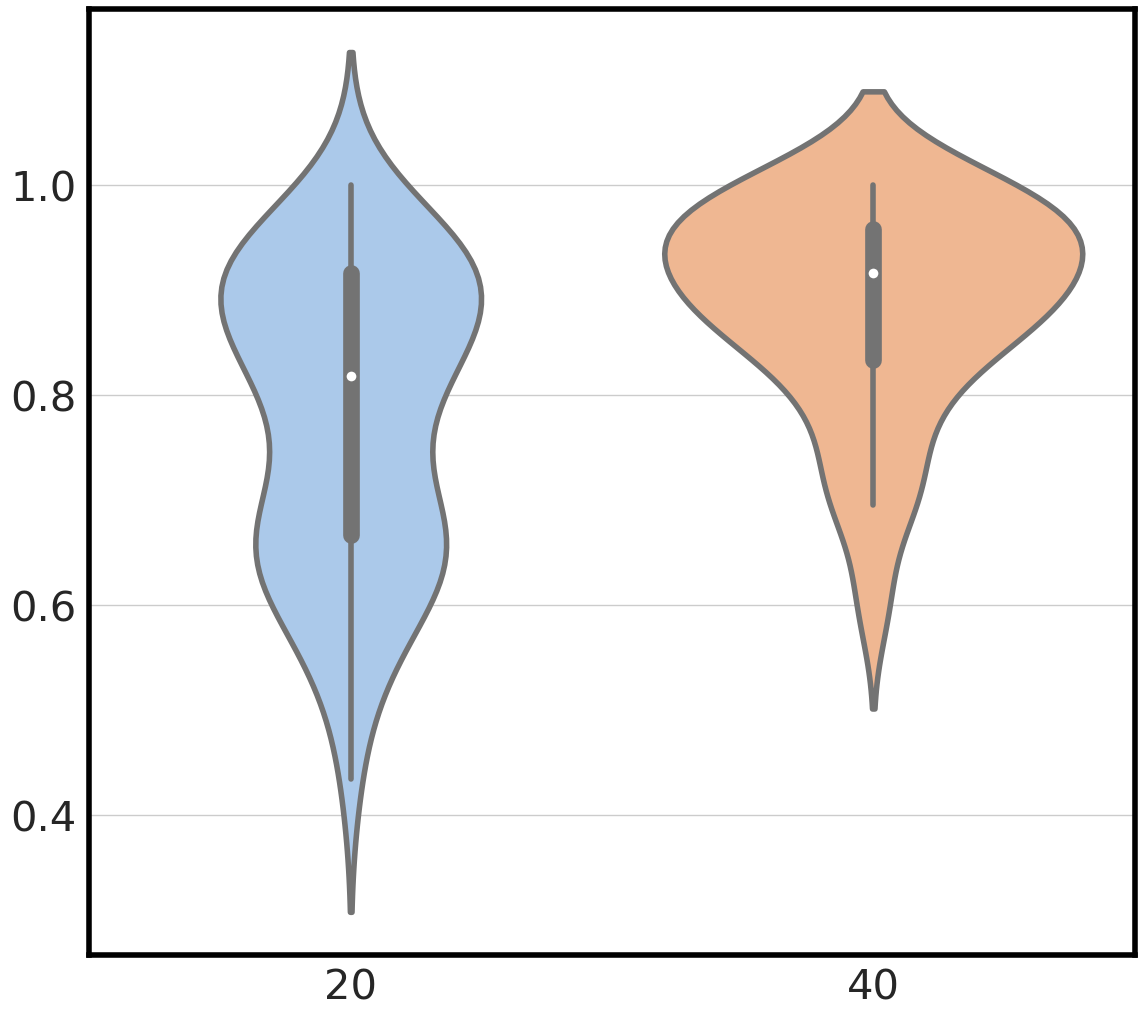

In [15]:
# violinplot to show generalisation performance

plot_gen_df = deepcopy(gen_df)

plot_gen_df['correctness'] = pd.to_numeric(plot_gen_df["correctness"], errors='coerce')

# keep only correctness, subject and block columns
plot_gen_df = plot_gen_df[['correctness', 'subject', 'block']]

# average over subject
plot_gen_df = plot_gen_df.groupby(['subject', 'block']).mean().reset_index()

sns.set_theme(style="whitegrid", palette="pastel")


g = sns.catplot(
            x="block",  
            y="correctness",
            data=plot_gen_df,
            kind='violin',
            height = 4,
            aspect = 1.2,
            legend=True,
            orient='v',
            # make lines thicker
            linewidth=4)

# removex and y labels
plt.ylabel('')
plt.xlabel('')

# make plot sized 12cm high, 13cm wide
plt.gcf().set_size_inches(13, 12)
'''
# make catplot lines thicker, and dark grey 
for axis in ['top','bottom','left','right']:
    g.ax.spines[axis].set_linewidth(4)
    g.ax.spines[axis].set_color('darkgrey')
# same for ticks
g.ax.tick_params(width=4, color='darkgrey')
'''

# display top and right spines
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)


plt.gca().spines['top'].set_linewidth(4)
plt.gca().spines['right'].set_linewidth(4)
plt.gca().spines['left'].set_linewidth(4)
plt.gca().spines['bottom'].set_linewidth(4)
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')

# make labels a lot bigger
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.show()


In [10]:
# describe plot_gen_df after 20 blocks

plot_gen_df.loc[plot_gen_df['block'] == 40].describe()

,block,state,position,chosen position,rt,correctness,time,rule,times chosen,abstract position,abstract position 10,abstract position chosen,abstract position chosen 10
count,57.0,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.0,57.000000,57.000000,57.000000
mean,40.0,128.461988,104.970760,104.866465,1.243317,0.885208,4883.873548,0.052632,0.145468,2.5,4.970760,2.390865,4.898623
std,0.0,2.897303,0.271173,1.550173,0.132500,0.100082,270.059745,0.242896,0.057392,0.0,0.271173,0.195177,0.421111
min,40.0,123.583333,104.375000,98.227273,0.998835,0.590909,4380.971741,-0.541667,0.041667,2.5,4.375000,1.826087,4.000000
25%,40.0,125.791667,104.791667,104.666667,1.161988,0.833333,4682.249224,-0.125000,0.125000,2.5,4.791667,2.291667,4.583333
50%,40.0,128.375000,105.000000,105.083333,1.236601,0.916667,4839.575107,0.041667,0.125000,2.5,5.000000,2.434783,4.833333
75%,40.0,131.000000,105.208333,105.333333,1.312848,0.958333,5024.797882,0.208333,0.166667,2.5,5.208333,2.541667,5.250000
max,40.0,133.208333,105.416667,108.565217,1.542285,1.000000,5771.149400,0.583333,0.291667,2.5,5.416667,2.750000,6.041667


In [12]:
mean_gen.head()

,subject,block,correctness
0,sub-1,20,0.791667
1,sub-1,40,1.000000
2,sub-10,20,0.652174
3,sub-10,40,0.875000
4,sub-11,20,0.875000


In [ ]:
test_df = deepcopy(test_data.loc[test_data['guided'] == 'TEST'])

# Performance in test blocks

/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/data/u_eperon_software/anaconda3/envs/act_hippo/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: us

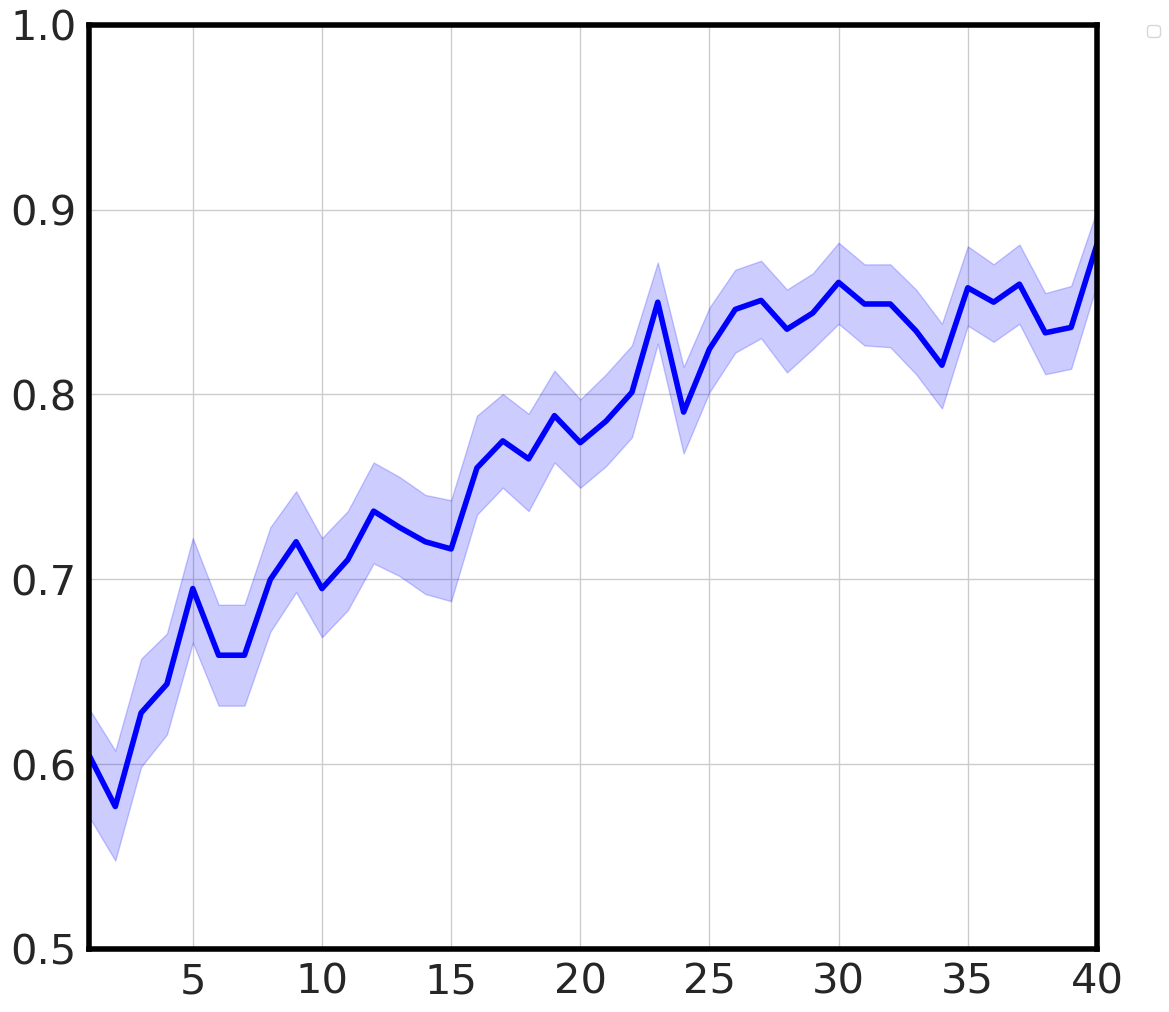

In [20]:
sns.set_theme(style="whitegrid", palette="pastel")


# new df where nan values in correctness set as 0
plot_test_df = deepcopy(test_df)
plot_test_df['correctness'] = plot_test_df['correctness'].fillna(0)

g = sns.lineplot(x="block", y="correctness",
            data=plot_test_df,
            #hue='subject',
            errorbar=('ci', 95),
            # line thickness of 4
            linewidth=4,
            # brighter colour blue
            color='blue'
            ) 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
#plt.title('Performance in test phase by learning block')
#plt.xlim(0, 15)


# hide legend
#plt.legend().set_visible(False)

# resize to 12cm high, 13cm wide
plt.gcf().set_size_inches(13, 12)

# set y limit as 0 to 1
plt.ylim(0.5, 1)

# remove all labels
plt.ylabel('')
plt.xlabel('')

# change font size of x labels to 30
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)


# display top and right spines
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)


plt.gca().spines['top'].set_linewidth(4)
plt.gca().spines['right'].set_linewidth(4)
plt.gca().spines['left'].set_linewidth(4)
plt.gca().spines['bottom'].set_linewidth(4)
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# set xlim as 1 to 40
plt.xlim(1, 40)


plt.show()


In [16]:
# average performance in block 1
# average by subject
plot_test_df.loc[plot_test_df['block'] >= 35].groupby(['subject'])['correctness'].mean().reset_index().describe()

,correctness
count,57.000000
mean,0.852989
std,0.075183
min,0.666667
25%,0.805556
50%,0.861111
75%,0.916667
max,0.962963


# Plot RT in test trials by state identity

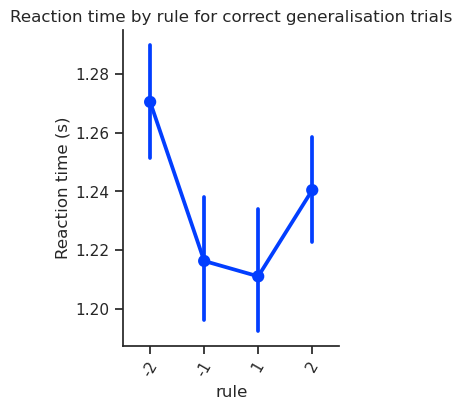

In [27]:
sns.set_theme(style="ticks", palette="bright")


g = sns.catplot(x="rule", y="rt",
            #hue="subject",
            data=gen_df.loc[(gen_df['correctness'] ==1)], 
            kind='point',
            height = 4,
            aspect = 0.8,
            legend=False,
            dodge=True,
            errorbar=('ci', 95),
            orient='v',
            #color='turquoise'   
               )
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Reaction time by rule for correct generalisation trials')
g.set(ylabel='Reaction time (s)')
plt.xticks(rotation=60) 
plt.show()


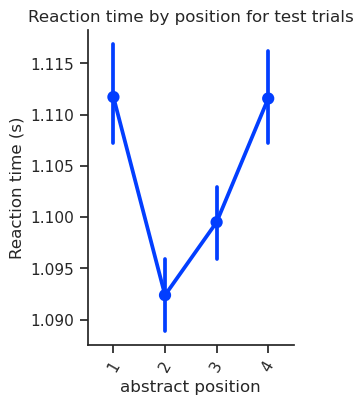

In [28]:
sns.set_theme(style="ticks", palette="bright")


g = sns.catplot(x="abstract position", y="rt",
            #hue="subject",
            data=test_df, 
            kind='point',
            height = 4,
            aspect = 0.8,
            legend=False,
            dodge=True,
            errorbar=('ci', 95),
            orient='v',
            #color='turquoise'   
               )
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Reaction time by position for test trials')
g.set(ylabel='Reaction time (s)')
plt.xticks(rotation=60) 
plt.show()
